# LAB 10

## Esercizio 10.1

In questo esercizio il problema del Travelling Salesman Problem (TSP) è stato affrontato mediante una parallelizzazione dell’algoritmo genetico sviluppato nelle esercitazioni precedenti, utilizzando le librerie MPI (Message Passing Interface). Tra le due possibilità proposte dalla consegna viene scelta la prima strategia, cioè l’implementazione di una ricerca genetica parallela composta da più popolazioni indipendenti che evolvono simultaneamente su processi differenti. L’idea alla base di questo approccio è il cosiddetto *modello a continenti* (*island model*): ogni processo MPI evolve autonomamente una propria popolazione di percorsi candidati, applicando gli stessi operatori genetici già sviluppati in precedenza (selezione, crossover e mutazioni). Periodicamente, però, i vari continenti comunicano tra loro scambiandosi le migliori soluzioni trovate fino a quel momento, in modo da favorire una diffusione globale delle configurazioni più promettenti.

La parallelizzazione è stata realizzata tramite la libreria MPI. All’inizio dell’esecuzione ogni processo viene identificato tramite il proprio `rank`:
`MPI_Comm_rank(MPI_COMM_WORLD, &rank);`
`MPI_Comm_size(MPI_COMM_WORLD, &size);`
dove `rank` identifica il singolo continente e `size` rappresenta il numero totale di processi utilizzati nella simulazione. Ogni processo inizializza un generatore di numeri casuali indipendente, modificando opportunamente il seed iniziale mediante il valore del rank. In questo modo ogni continente evolve una popolazione differente ed esplora regioni diverse dello spazio delle configurazioni. Tutti i processi leggono la stessa configurazione del problema TSP, ma l’evoluzione genetica avviene in maniera indipendente fino ai momenti di migrazione. L’aspetto fondamentale della parallelizzazione consiste nello scambio periodico di informazione tra continenti: ogni $N_{migr}$ generazioni vengono scelti casualmente due processi MPI e ciascuno invia all’altro il proprio miglior individuo. Lo scambio viene effettuato tramite le funzioni MPI: 
- `MPI_Bcast(...)`: viene utilizzata per comunicare a tutti i processi quali continenti parteciperanno alla migrazione. Prima di utilizzare questa funzione, infatti, il processo 0 ha estratto la coppia di processi tra cui avviene lo scambio di individui (ciò si ripete ad ogni $N_{migr})$. 
- `MPI_Sendrecv(...)`: permette lo scambio simultaneo dei migliori percorsi tra i due rank selezionati.
Una volta ricevuto il nuovo individuo, ciascun continente sostituisce il proprio individuo peggiore con quello migrato tramite la funzione `GA.ReplaceWorst(migrant)`. 

## Esercizio 10.2

In questo esercizio il codice parallelo sviluppato nell'Esercizio 10.1 è stato applicato alla risoluzione del Travelling Salesman Problem per le 110 città italiane contenute nel file `cap_prov_ita.dat`. L'obiettivo principale è verificare se l'introduzione di un meccanismo di migrazione tra processi MPI produca un effettivo miglioramento rispetto all'utilizzo dello stesso numero di processi che eseguono ricerche genetiche completamente indipendenti.

Come discusso nell'esercizio precedente, ciascun processo MPI rappresenta un continente che evolve autonomamente una propria popolazione di percorsi. Nel caso con migrazione, ogni $N_{migr} = 50$ generazioni vengono selezionati casualmente due continenti che si scambiano il proprio miglior individuo; il percorso ricevuto sostituisce quindi l'individuo peggiore della popolazione locale. Nel caso senza migrazione, invece, i continenti evolvono in maniera completamente indipendente per tutta la durata della simulazione.

Per effettuare il confronto sono state eseguite due simulazioni utilizzando lo stesso numero di processi ($N_{proc} = 11$), la stessa popolazione iniziale (composta da 1000 individui), gli stessi operatori genetici e lo stesso numero di generazioni ($N_{gen}=2000$). L'unica differenza consiste nell'attivazione o meno del meccanismo di migrazione tramite una variabile booleana. 

#### EVOLUZIONE DELLA FITNESS

Il primo grafico mostra l'andamento della lunghezza del miglior percorso trovato da ciascun continente durante l'evoluzione genetica; il grafico si riferisce alla simulazione con le migrazioni.

Dal grafico si osserva come tutti i continenti presentino una rapida diminuzione della lunghezza del miglior percorso nelle prime generazioni, seguita da una progressiva fase di stabilizzazione. Nonostante le popolazioni partano da configurazioni casuali differenti, l'introduzione della migrazione favorisce una convergenza verso valori molto simili della fitness finale. La linea orizzontale tratteggiata rappresenta il miglior valore ottenuto complessivamente e permette di evidenziare come la maggior parte dei continenti riesca ad avvicinarsi a tale soluzione.

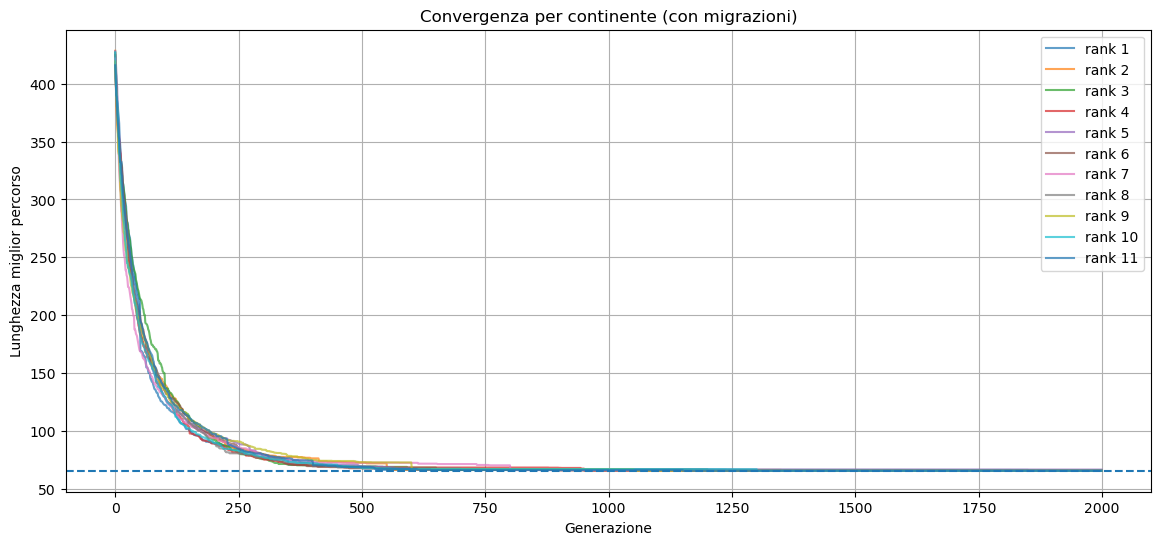

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for i in range(11):
    data = np.loadtxt(f"Output/With_migration/best_rank_{i}.dat")
    plt.plot(data[:,0], data[:,1], alpha=0.7, label=f"rank {i+1}")

plt.xlabel("Generazione")
plt.ylabel("Lunghezza miglior percorso")
plt.axhline(y=65.7206, linestyle='--')
plt.title("Convergenza per continente (con migrazioni)")
plt.legend()
plt.grid()

plt.show()

Per apprezzare meglio il comportamento iniziale dell'algoritmo, è utile osservare un ingrandimento delle prime generazioni utilizzando una scala logaritmica sull'asse delle ordinate. La rappresentazione logaritmica mette in evidenza la rapidità con cui l'algoritmo elimina le configurazioni peggiori durante le prime fasi dell'evoluzione. Si nota inoltre come i diversi continenti seguano traiettorie inizialmente differenti, a causa delle diverse popolazioni di partenza, ma tendano progressivamente a convergere verso regioni molto simili dello spazio delle soluzioni. Questo comportamento suggerisce che lo scambio periodico di individui migliori favorisca la diffusione delle configurazioni più promettenti tra le diverse popolazioni.

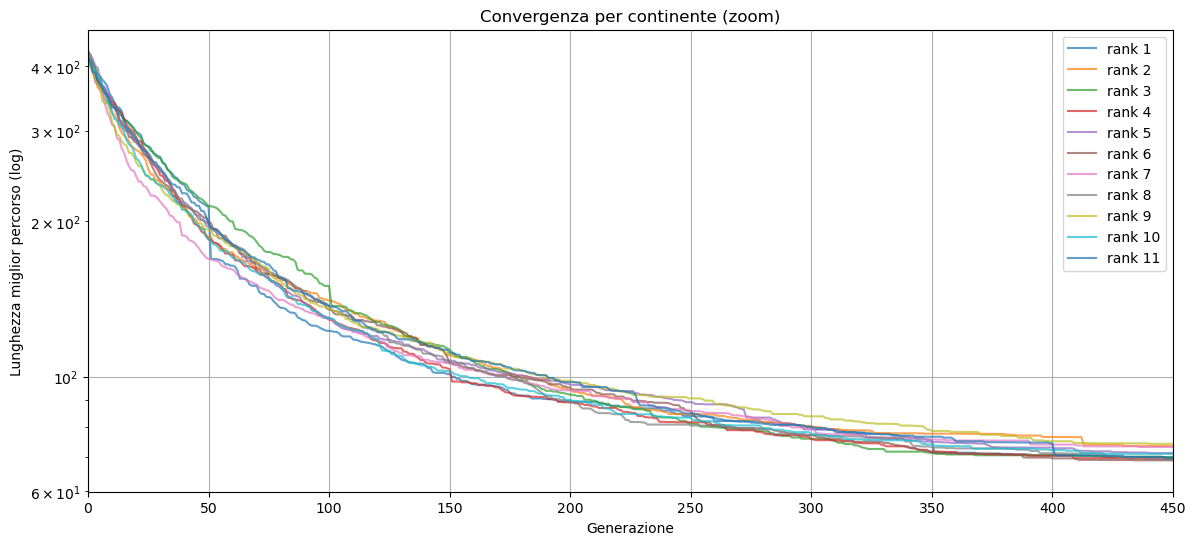

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for i in range(11):
    data = np.loadtxt(f"Output/With_migration/best_rank_{i}.dat")
    plt.plot(data[:,0], data[:,1], alpha=0.7, label=f"rank {i+1}")

plt.xlabel("Generazione")
plt.ylabel("Lunghezza miglior percorso (log)")
plt.yscale('log')
plt.title("Convergenza per continente (zoom)")
plt.legend()
plt.grid()
plt.xlim(0, 450) #zoom

plt.show()

#### PERCORSI FINALI (CON MIGRAZIONI)

Per comprendere l'effetto della comunicazione tra continenti è utile confrontare direttamente i percorsi migliori ottenuti al termine della simulazione.

Ogni pannello mostra il miglior percorso trovato da uno dei continenti nel caso con migrazione. Sebbene le configurazioni non siano identiche, si osserva una notevole somiglianza nella struttura globale dei percorsi e nei valori finali della fitness riportati sotto ciascun grafico. Questo comportamento indica che l'informazione contenuta nei migliori individui tende a propagarsi tra le popolazioni, guidando l'evoluzione verso regioni particolarmente favorevoli dello spazio delle configurazioni. La migrazione agisce quindi come un meccanismo di cooperazione tra processi: ogni continente continua a esplorare autonomamente nuove configurazioni, ma beneficia anche delle buone soluzioni individuate dagli altri continenti.

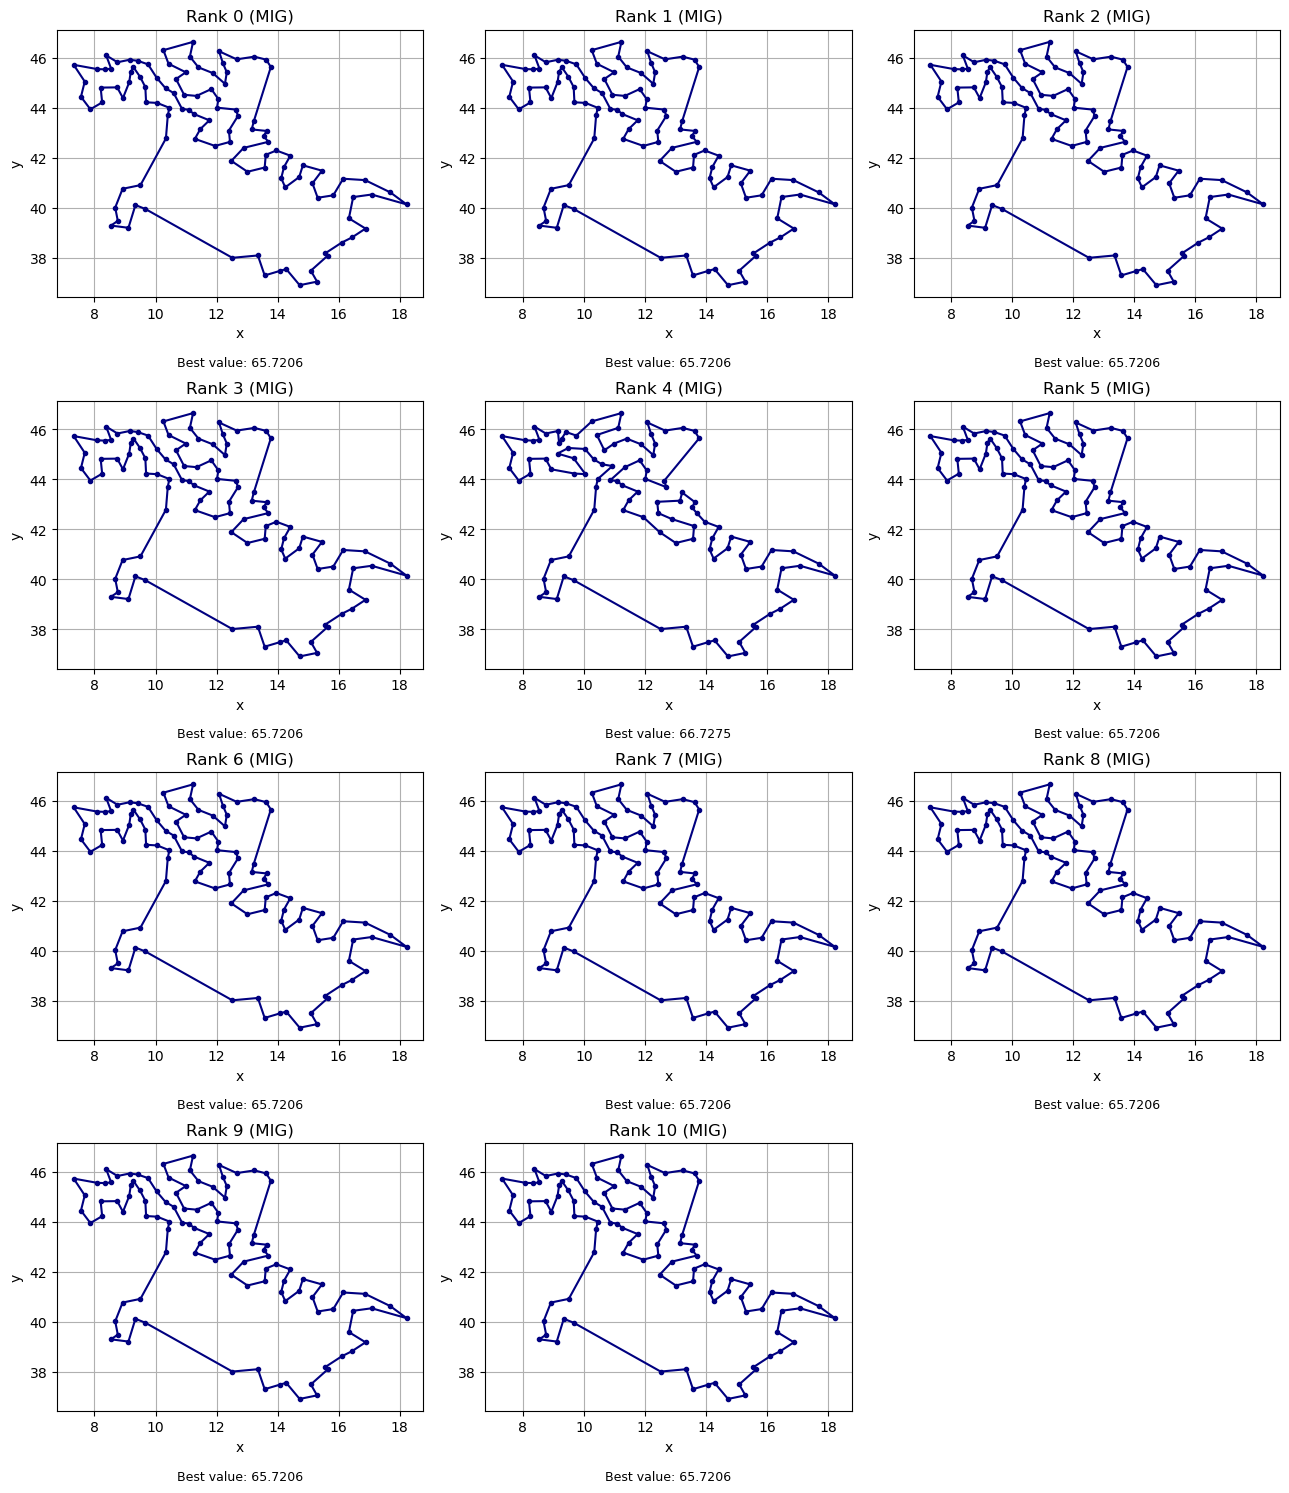

In [8]:
import numpy as np
import matplotlib.pyplot as plt

n_ranks = 11

fig, axes = plt.subplots(4, 3, figsize=(13, 15))
axes = axes.flatten()

for rank in range(n_ranks):
    path = np.loadtxt(f"Output/With_migration/best_path_rank_{rank}.dat")

    x = path[:, 0]
    y = path[:, 1]

    ax = axes[rank]
    ax.plot(x, y, marker="o", markersize=3, color='navy')
    ax.plot([x[-1], x[0]], [y[-1], y[0]], color='navy')  # chiusura ciclo

    ax.set_title(f"Rank {rank} (MIG)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid()

    
    best_data = np.loadtxt(f"Output/With_migration/best_rank_{rank}.dat")
    last_value = best_data[-1, 1]   # seconda colonna

    ax.text(
        0.5, -0.22,
        f"Best value: {last_value:.4f}",
        ha='center',
        va='top',
        transform=ax.transAxes,
        fontsize=9
    )


for i in range(n_ranks, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### PERCORSI FINALI (SENZA MIGRAZIONE)

Per confronto, il grafico seguente mostra i migliori percorsi ottenuti quando la migrazione viene completamente disattivata.

In questo caso ogni continente evolve in maniera totalmente indipendente e l'unica fonte di diversificazione è costituita dalle differenti condizioni iniziali. I percorsi finali mostrano una maggiore variabilità e anche i valori finali della fitness risultano generalmente più dispersi. Alcuni continenti riescono comunque a trovare soluzioni di buona qualità, mentre altri rimangono bloccati in minimi locali meno favorevoli. L'assenza di comunicazione impedisce infatti alle informazioni utili di diffondersi tra le diverse popolazioni. Di conseguenza, il successo di una singola ricerca dipende esclusivamente dalla propria storia evolutiva e dalla capacità di uscire autonomamente da eventuali minimi locali.

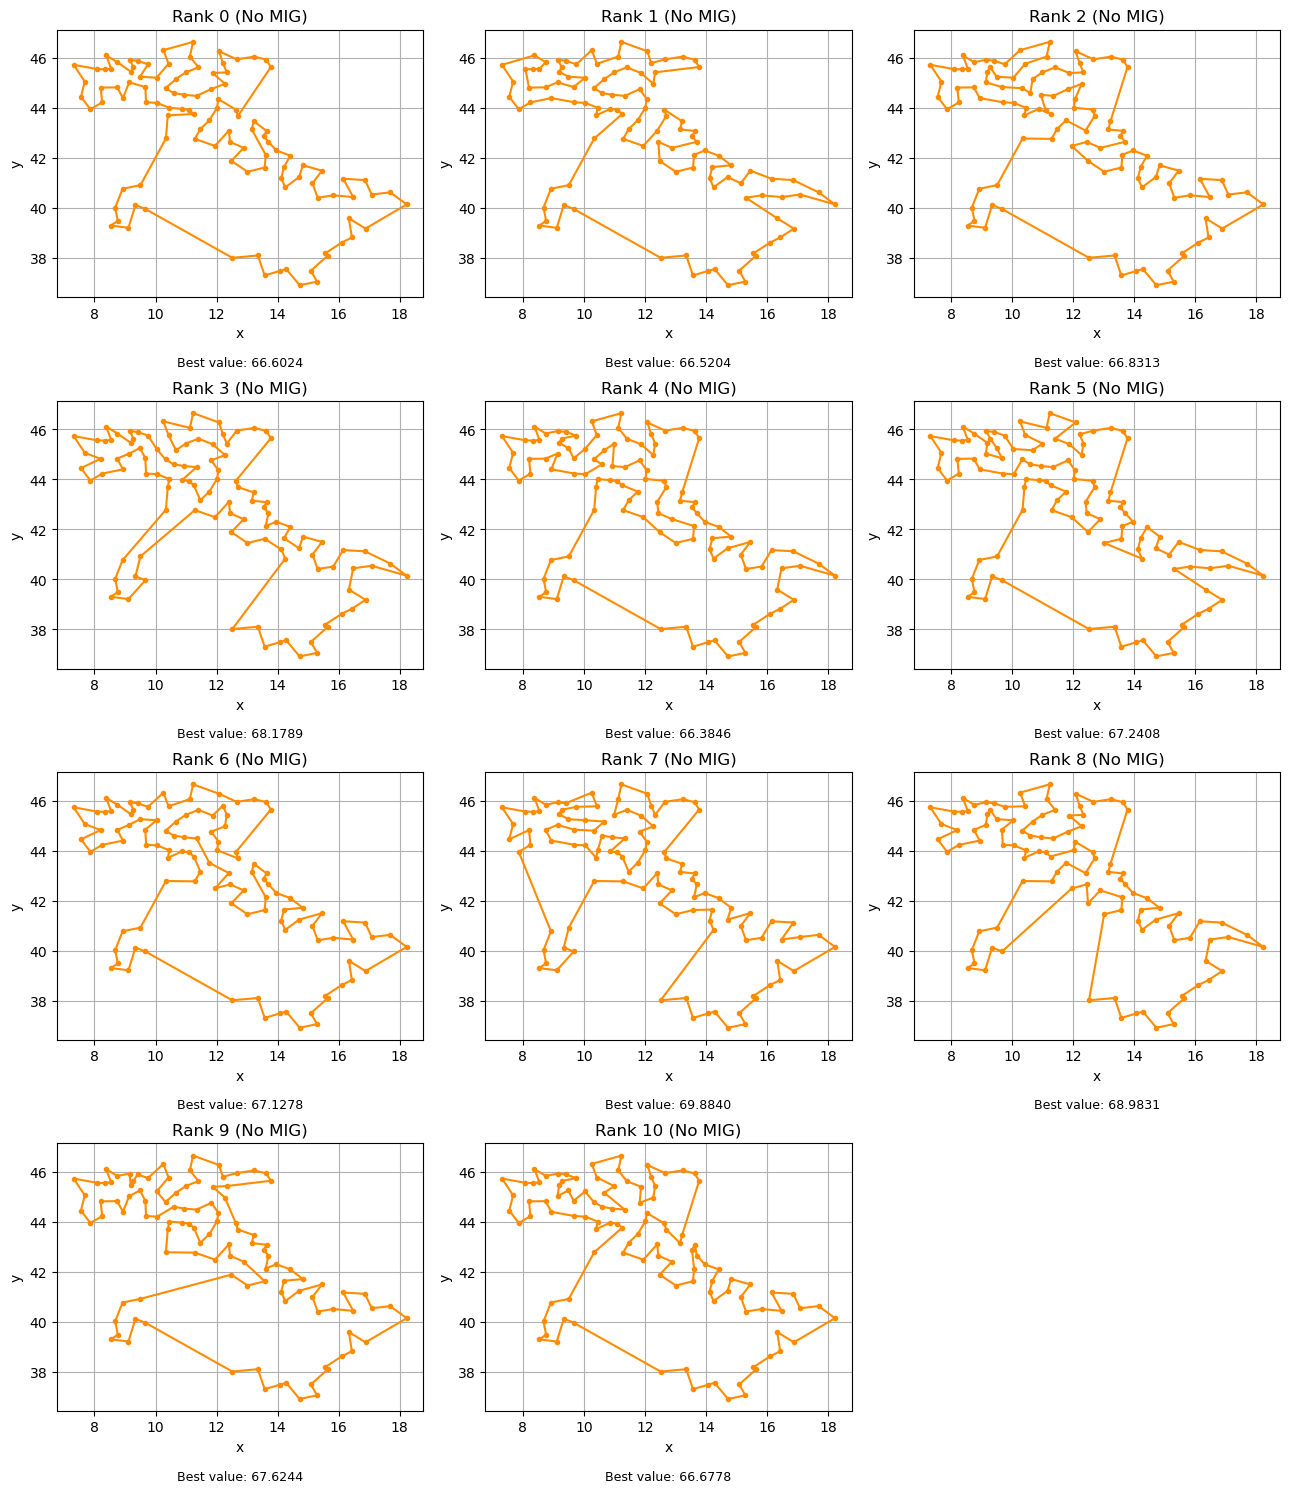

In [9]:
import numpy as np
import matplotlib.pyplot as plt

n_ranks = 11

fig, axes = plt.subplots(4, 3, figsize=(13, 15))
axes = axes.flatten()

for rank in range(n_ranks):
    path = np.loadtxt(f"Output/No_migration/best_path_rank_{rank}.dat")

    x = path[:, 0]
    y = path[:, 1]

    ax = axes[rank]
    ax.plot(x, y, marker="o", markersize=3, color='darkorange')
    ax.plot([x[-1], x[0]], [y[-1], y[0]], color='darkorange')  # chiusura ciclo

    ax.set_title(f"Rank {rank} (No MIG)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid()

    
    best_data = np.loadtxt(f"Output/No_migration/best_rank_{rank}.dat")
    last_value = best_data[-1, 1]   # seconda colonna

    ax.text(
        0.5, -0.22,
        f"Best value: {last_value:.4f}",
        ha='center',
        va='top',
        transform=ax.transAxes,
        fontsize=9
    )


for i in range(n_ranks, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### CONCLUSIONI

Il confronto tra le simulazioni con e senza migrazioni mostra chiaramente il vantaggio introdotto dal modello a continenti. Nel caso con migrazioni la lunghezza del miglior percorso è pari a 65.7206 per quasi tutti i processi. Invece, nel caso senza migrazioni le lunghezze sono piuttosto differenti tra i vari rank: il miglior rank ha ottenuto una lunghezza di 66.3846, mentre il peggiore di 69.8840; si vede quindi come in ogni caso risulti vantaggiosa la simulazione con migrazioni. 

Si conclude quindi che la parallelizzazione tramite MPI non rappresenta soltanto un modo per distribuire il carico computazionale, ma costituisce anche un efficace strumento per migliorare l'efficienza dell'algoritmo genetico nella ricerca della soluzione ottimale del problema. 

## Cosa ho fatto:
mi collego da ssh da VScode e poi faccio `module load mpi/openmpi-x86_64` (ogni volta che apro un nuovo temporale) 

Nello scorso esercizio avevamo una sola "macchina logica" che lavora, una popolazione unica di soluzioni e un ciclo (selezione -> crossover -> mutazione -> nuova generazione). Si tratta quindi di un processo seriale (tutto in fila). Invece, quando parliamo di paralelizzazione si hanno più copie che lavorano contemporaneamente. 
L'idea chiave è che abbiamo 11 "Continents" (cioè 11 GA indipendenti), dove ogni continente ha la sua poplazione, fa il suo genetic algoritm e non comuntica continuamente con gli altri. Abbiamo però una libreria MPI che serve per far comuniucare i processi separati: in questo modo, ogni processo ha la sua memoria, il suo lavoro e può inviare/ricevere messaggi dagli altri. 

Quello che succede che che ogni N_migr generazioni si ha la MIGRAZIONE, ovvero i continenti si scambiano gli individui migliori. 

Ogni processo ha un rank, ovvero un identificatore che permette di capire chi è e con chi sta comunicando. 

#### Codice:
**Inizializzazione** : viene utilizzata la funzione `MPI_Init` che inizializza tutto l'ambiente MPI, ovvero crea i processi
prepara le comunicazioni e sincronizza i nodi. Deve essere la PRIMA cosa MPI del programma.

**Ottenere rank e size**:
- `MPI_Comm_rank(MPI_COMM_WORLD, &rank)`: restituisce il rank del processo
- `MPI_Comm_size(MPI_COMM_WORLD, &size)`: restituisce quanti processi esistono

**Seed**
Ogni processo deve avere il suo GA: sono tutti indipendenti e hanno tutti seed random differente (infatti se tutti hanno lo stesso seed fanno la stessa evoluzione e la paralelizzazione risulta inutile). Per mettere i seed diversi faccio: `rnd.SetSeed(seed + rank)`. 

**Loop principale su generazione** 
Dentrop questo loop ho l'evoluzione del sistema con `GA.Evolve(rnd)`. Poi c'è la migrazione. Ogni N_migr generazioni si trova il miglior individuo, viene mandato ad un altro continente; inoltre viene ricevuto un individuo che viene sostituito al peggiore. 

Per mandare l'individuo viene utilizzata la funzione `MPI_Send(data, count, datatype, dest, tag, communicator)`, dove data è un puntatore ai dati, count indica quanri elementi mandare, datatype il tipo dei dati (MPI_INT, MPI_DOUBLE...), dest è il destinatario, tag è l'etichetta del messaggio e communicator è MPI_COMM_WORLD. 
Analogamente, per ricevere si utilizza MPI_Recv(data, count, datatype, source, tag, communicator, status);

Per i grafici con e senza migrazione ho usato una variabile booleana per attiviare e disattivar una parte di codice-



Plot da fare: 
- convergenza di GA (con migrazione): plot con tutte le righe
- confronto della convergenza tra migrazione e non migrazione (farlo per una sola riga)
- plot delle città con sotto la lunghezza del percorso (sia migrazione che senza)
  
